# Clusterizador com Local Outlier Factor

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import LocalOutlierFactor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

## Ler Dados

In [65]:
df_stars = pd.read_csv("./dataset/pulsar.csv")
df_stars.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Mean of the integrated profile                17898 non-null  float64
 1   Standard deviation of the integrated profile  17898 non-null  float64
 2   Excess kurtosis of the integrated profile     17898 non-null  float64
 3   Skewness of the integrated profile            17898 non-null  float64
 4   Mean of the DM-SNR curve                      17898 non-null  float64
 5   Standard deviation of the DM-SNR curve        17898 non-null  float64
 6   Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7   Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                  17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [66]:
df_stars.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


## Distribuição da Variável Target

In [67]:
df_stars.value_counts('target_class', normalize=True) * 100 # type: ignore

target_class
0    90.842552
1     9.157448
Name: proportion, dtype: float64

## Tratar Dados

In [68]:
X = df_stars.drop(columns=['target_class'])
y = df_stars['target_class']

colunas_numericas = X.columns.tolist()

preprocessor = ColumnTransformer(transformers=[
  ('num', StandardScaler(), colunas_numericas)
])

X_transformed = preprocessor.fit_transform(X)

## Treinar modelo

In [69]:
model_lof = LocalOutlierFactor(
  n_neighbors=300,
  contamination=0.09,
  metric='minkowski',
  p=2,
  n_jobs=-1,
)

In [70]:
y_pred = model_lof.fit_predict(X_transformed)

In [71]:
y_pred[:20]

array([ 1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1])

## Métricas

### Adequar y_pred para a variável target

In [72]:
y_pred = [1 if item == -1 else 0 for item in y_pred]

In [73]:
df_stars['cluster'] = y_pred

### Matriz de Confusão

In [74]:
conf_matrix = confusion_matrix(df_stars['target_class'], df_stars['cluster'])

Text(0.5, 1.0, 'Confusion Matrix')

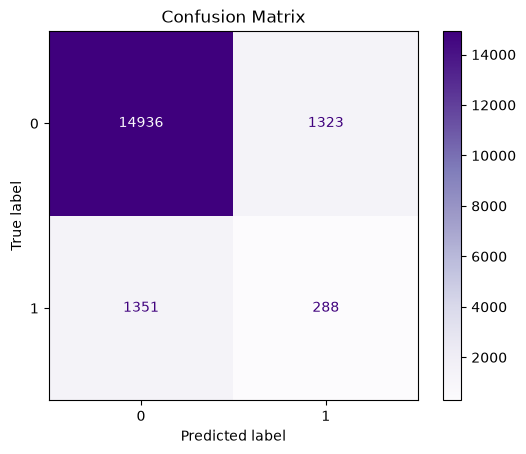

In [75]:
cmd = ConfusionMatrixDisplay(conf_matrix)
cmd.plot(
  cmap='Purples',
)
plt.title("Confusion Matrix")